# Case
**Convert vector data with continuous values into raster format**

The labels are either based on a provided text- or Esri-shapefile.<br>
To spatially align the labels with other data sets, a template raster (base raster) can be provided.


In [33]:

import numpy as np
import geopandas as gpd

import sys
if sys.version_info < (3, 9):
    from importlib_resources import files
else:
    from importlib.resources import files

import rasterio
from beak.experimental.utilities.conversions import create_continuous_raster
from beak.experimental.utilities.raster_processing import snap_raster
from beak.experimental.utilities.io import save_raster


# Load data

**User definitions**

For a projected **CRS** (such as EPSG:**102008**), use the metric system to provide the resolution (e.g., 2250 m).<br>
For a geographic **CRS** (such as EPSG:**4326**), use degrees to provide the resolution (e.g. 0.025 deg).<br>

**Note**
The input shapefile/geopackage must be in the same CRS as the target base raster.<br>

In [34]:
# Set paths
BASE_PATH = files("beak.data")

PATH_BASE_RASTER = BASE_PATH / "BASE_RASTERS" / "EPSG_102008_RES_500_MAMA_NICO_UPMIDWEST.tif"
PATH_SHAPEFILE = BASE_PATH / "RAW" / "geology" / "data_ta2" / "regional_scale" / "nico_uppermidwest" / "regional_cu_ni_pge_duluth.gpkg"
COLUMN = "bge_deposit_type"

OUT_FILE = "test_continuous_raster.tif"

# Reference coordinate system code
QUERY = None
RESOLUTION = 500

nodata = -99999
base_raster = rasterio.open(PATH_BASE_RASTER)



Show coverage of shapefile

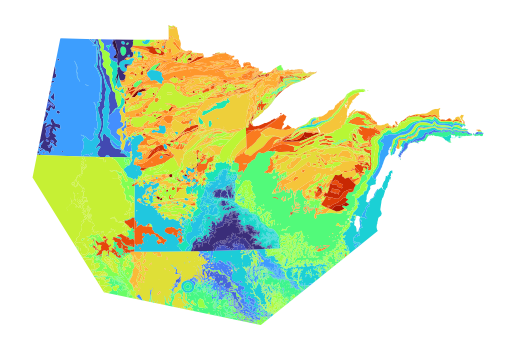

In [35]:
import matplotlib.pyplot as plt

gdf = gpd.read_file(PATH_SHAPEFILE, layer="intersection")
cmap = "turbo"

if QUERY is not None:
  gdf.query(QUERY).plot(column=COLUMN, cmap=cmap)
else:
  gdf.plot(column=COLUMN, cmap=cmap)
  
plt.axis("off")
plt.show()


# Create Continuous Raster

In [36]:
# Load shapefile and create geodataframe
gdf = gpd.read_file(PATH_SHAPEFILE)
gdf = gdf.to_crs(base_raster.crs)

In [37]:
# Create raster without snap. Remove the `snap_to_origin=None` statement or provide a base raster for automatic alignment.
raster_array, raster_meta = create_continuous_raster(
    geodataframe=gdf,
    column=COLUMN,
    base_raster=None,
    resolution=500,
    query=QUERY,
    out_file=None,
    nodata=nodata,
    snap_to_origin=None,
    )


Rasterized without alignment: (1837, 2439)


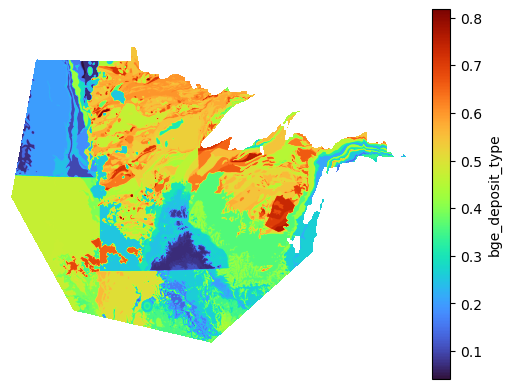

In [38]:
cmap = "turbo"
fig, ax = plt.subplots(nrows=1, ncols=1)
cax = ax.imshow(np.where(raster_array == nodata, np.nan, raster_array), cmap=cmap)
ax.axis("off")

# Add colorbar (legend)
cbar = fig.colorbar(cax, ax=ax, orientation='vertical')
cbar.set_label(COLUMN)

print(f"Rasterized without alignment: {raster_array.shape}")
plt.show()

In [39]:
# Separate alginment
snapped_array, snapped_meta = snap_raster(
    raster=(raster_array, raster_meta), snap_to=base_raster
)


In [40]:
save_raster(path=OUT_FILE, array=snapped_array, metadata=snapped_meta, dtype=snapped_array.dtype, overwrite=True)